# 02 — Famous Three-Body Orbits

This notebook runs and visualizes all six canonical configurations in the catalogue.

| Configuration | Type | Stability | Year |
|--------------|------|-----------|------|
| Figure-Eight | Choreography | Stable (isolated) | 1993/2000 |
| Lagrange Triangle | Periodic | Stable (equal mass) | 1772 |
| Pythagorean | Chaotic | Unstable → ejection | 1913 |
| Sun-Jupiter-Saturn | Hierarchical | Long-term stable | — |
| Figure-Eight Perturbed | Chaotic | Unstable | — |
| Sun-Earth-Moon | Hierarchical | Stable | — |

**Physics goal:** Understand why some configurations are stable and others are chaotic.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from src.core.initial_conditions import CATALOGUE, build_state_vector
from src.core.integrator import integrate_scipy
from src.core.equations import transform_to_cm_frame
from src.visualization.visualize import BODY_COLORS
from src.analysis.analysis import detect_ejection, minimum_separation

print('✓ Ready')

✓ Ready


## Helper: run any configuration

In [2]:
def run_config(name, rtol=1e-10, atol=1e-12, n_points=6000):
    ic = CATALOGUE[name]()
    masses = np.array([ic['m1'], ic['m2'], ic['m3']])
    r1,r2,r3,v1,v2,v3 = transform_to_cm_frame(
        ic['r1'],ic['r2'],ic['r3'],
        ic['v1'],ic['v2'],ic['v3'], *masses)
    ic.update({'r1':r1,'r2':r2,'r3':r3,'v1':v1,'v2':v2,'v3':v3})
    y0 = build_state_vector(ic)
    t_end = ic.get('t_end', 20.0)
    t_eval = np.linspace(0, t_end, n_points)
    result = integrate_scipy(y0, masses, (0,t_end), t_eval,
                             method='DOP853', rtol=rtol, atol=atol)
    return ic, result

## 1. Figure-Eight Choreography
Three equal masses chase each other on a figure-8 path. A **periodic choreography** — all bodies share the same orbit shifted by T/3.

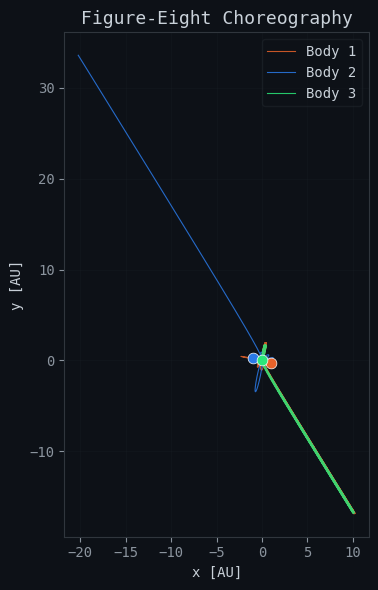

Max ΔE/E₀ = 1.60e-02  |  Duration = 20.0 yr


In [3]:
ic, res = run_config('figure_eight')
pos = res.positions

fig, ax = plt.subplots(figsize=(9,6))
for b, c in enumerate(BODY_COLORS):
    ax.plot(pos[:,b,0], pos[:,b,1], color=c, lw=0.8, alpha=0.85, label=f'Body {b+1}')
    ax.scatter(pos[0,b,0], pos[0,b,1], color=c, s=60, zorder=5, edgecolors='white', lw=0.5)
ax.set_title(ic['name'], fontsize=13)
ax.set_xlabel('x [AU]'); ax.set_ylabel('y [AU]')
ax.set_aspect('equal'); ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()
print(f'Max ΔE/E₀ = {res.max_energy_error:.2e}  |  Duration = {res.duration:.1f} yr')

## 2. Lagrange Equilateral Triangle
Lagrange (1772): bodies at vertices of an equilateral triangle rotating rigidly. The origin of **Lagrange points L4 and L5** — where Jupiter's Trojan asteroids live.

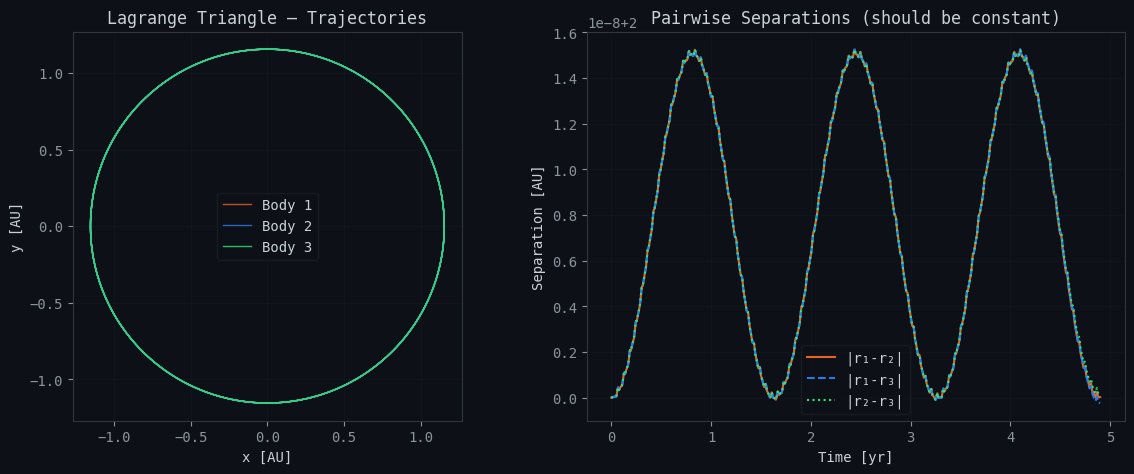

Separation variation: 1.5506e-08 AU  (should be ≈ 0)


In [4]:
ic, res = run_config('lagrange_triangle')
pos = res.positions

fig, axes = plt.subplots(1,2, figsize=(12,5))

# Trajectory plot
for b, c in enumerate(BODY_COLORS):
    axes[0].plot(pos[:,b,0], pos[:,b,1], color=c, lw=1, alpha=0.8, label=f'Body {b+1}')
axes[0].set_title('Lagrange Triangle — Trajectories')
axes[0].set_xlabel('x [AU]'); axes[0].set_ylabel('y [AU]')
axes[0].set_aspect('equal'); axes[0].legend(); axes[0].grid(True, alpha=0.2)

# Separation stays constant — prove it!
from src.analysis.analysis import separation_matrix
seps = separation_matrix(res)
axes[1].plot(res.t, seps[:,0], label='|r₁-r₂|', color=BODY_COLORS[0])
axes[1].plot(res.t, seps[:,1], label='|r₁-r₃|', color=BODY_COLORS[1], ls='--')
axes[1].plot(res.t, seps[:,2], label='|r₂-r₃|', color=BODY_COLORS[2], ls=':')
axes[1].set_title('Pairwise Separations (should be constant)')
axes[1].set_xlabel('Time [yr]'); axes[1].set_ylabel('Separation [AU]')
axes[1].legend(); axes[1].grid(True, alpha=0.2)

plt.tight_layout(); plt.show()
print(f'Separation variation: {(seps.max()-seps.min()):.4e} AU  (should be ≈ 0)')

## 3. Pythagorean Problem — Chaos!
Burrau (1913): masses 3,4,5 at rest at Pythagorean triangle vertices. **The lightest body gets ejected.** First numerically integrated by Burrau — a landmark in computational astrophysics.

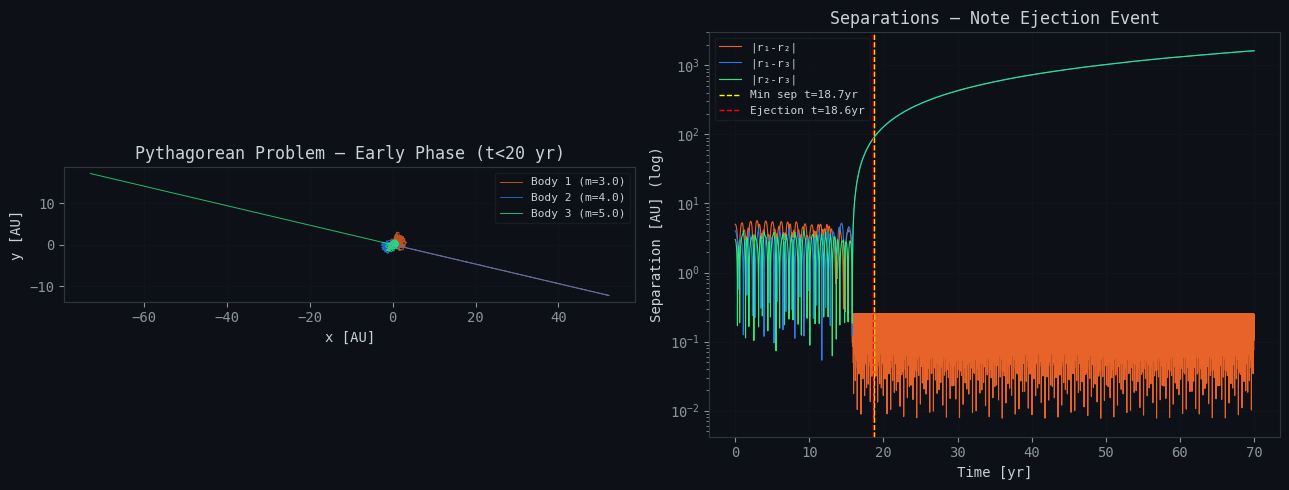

Minimum separation : 0.0077 AU (bodies 1-2 at t=18.72 yr)
Ejection detected  : Body 3 at t = 18.57 yr
Max ΔE/E₀          : 1.01e-02


In [5]:
ic, res = run_config('pythagorean', n_points=10000)
pos = res.positions

ejection = detect_ejection(res, threshold_au=50.0)
min_sep, t_close, pair = minimum_separation(res)
pairs = ['1-2','1-3','2-3']

fig, axes = plt.subplots(1,2,figsize=(13,5))

# Phase 1: early chaotic dance
mask_early = res.t < 20
for b,c in enumerate(BODY_COLORS):
    axes[0].plot(pos[mask_early,b,0], pos[mask_early,b,1], color=c, lw=0.7, alpha=0.8, label=f'Body {b+1} (m={ic[f"m{b+1}"]})')
axes[0].set_title('Pythagorean Problem — Early Phase (t<20 yr)')
axes[0].set_xlabel('x [AU]'); axes[0].set_ylabel('y [AU]')
axes[0].set_aspect('equal'); axes[0].legend(fontsize=8); axes[0].grid(True,alpha=0.2)

# Separation over time showing close encounter then ejection
seps = separation_matrix(res)
for i,(lbl,c) in enumerate(zip(['|r₁-r₂|','|r₁-r₃|','|r₂-r₃|'], BODY_COLORS)):
    axes[1].semilogy(res.t, seps[:,i]+1e-6, color=c, lw=0.8, label=lbl)
axes[1].axvline(t_close, color='yellow', ls='--', lw=1, label=f'Min sep t={t_close:.1f}yr')
if ejection:
    axes[1].axvline(ejection[1], color='red', ls='--', lw=1, label=f'Ejection t={ejection[1]:.1f}yr')
axes[1].set_title('Separations — Note Ejection Event')
axes[1].set_xlabel('Time [yr]'); axes[1].set_ylabel('Separation [AU] (log)')
axes[1].legend(fontsize=8); axes[1].grid(True,alpha=0.2)

plt.tight_layout(); plt.show()

print(f'Minimum separation : {min_sep:.4f} AU (bodies {pairs[pair]} at t={t_close:.2f} yr)')
if ejection:
    print(f'Ejection detected  : Body {ejection[0]+1} at t = {ejection[1]:.2f} yr')
print(f'Max ΔE/E₀          : {res.max_energy_error:.2e}')

## 4. Figure-Eight Perturbed — Lyapunov Instability

A tiny perturbation (0.01 AU) destroys the figure-8. This demonstrates the **Lyapunov exponent** — the same concept governing photon ring widths in Kerr spacetime.

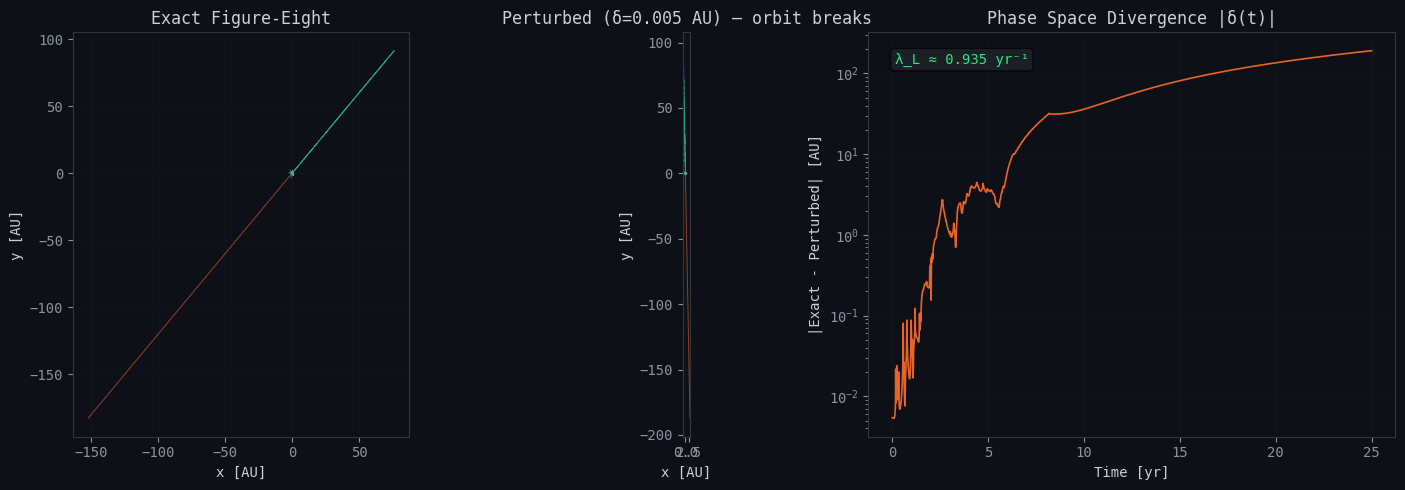

In [6]:
from src.core.initial_conditions import figure_eight, figure_eight_perturbed

# Run both: exact and perturbed
ic_exact = figure_eight(); ic_pert = figure_eight_perturbed(0.005)
masses = np.array([1.0,1.0,1.0])
t_end = 25.0; t_eval = np.linspace(0, t_end, 8000)

res_exact = integrate_scipy(build_state_vector(ic_exact), masses, (0,t_end), t_eval, method='DOP853', rtol=1e-12)
res_pert  = integrate_scipy(build_state_vector(ic_pert),  masses, (0,t_end), t_eval, method='DOP853', rtol=1e-12)

# Distance in phase space between the two trajectories
delta_pos = np.linalg.norm(
    res_exact.positions - res_pert.positions, axis=(1,2))

fig, axes = plt.subplots(1,3,figsize=(15,5))

for b,c in enumerate(BODY_COLORS):
    axes[0].plot(res_exact.positions[:,b,0], res_exact.positions[:,b,1], color=c, lw=0.7, alpha=0.6)
axes[0].set_title('Exact Figure-Eight'); axes[0].set_aspect('equal'); axes[0].grid(True,alpha=0.2)
axes[0].set_xlabel('x [AU]'); axes[0].set_ylabel('y [AU]')

for b,c in enumerate(BODY_COLORS):
    axes[1].plot(res_pert.positions[:,b,0], res_pert.positions[:,b,1], color=c, lw=0.7, alpha=0.6)
axes[1].set_title('Perturbed (δ=0.005 AU) — orbit breaks'); axes[1].set_aspect('equal'); axes[1].grid(True,alpha=0.2)
axes[1].set_xlabel('x [AU]'); axes[1].set_ylabel('y [AU]')

# Exponential divergence
axes[2].semilogy(res_exact.t, delta_pos + 1e-20, color='#E8632A', lw=1.2)
axes[2].set_title('Phase Space Divergence |δ(t)|')
axes[2].set_xlabel('Time [yr]'); axes[2].set_ylabel('|Exact - Perturbed| [AU]')
axes[2].grid(True,alpha=0.2)
# Fit exponential growth in early phase
mask = delta_pos > 1e-8
if mask.sum() > 10:
    t_fit = res_exact.t[mask][:50]
    d_fit = delta_pos[mask][:50]
    if len(t_fit) > 2 and d_fit[0] > 0:
        lam = np.polyfit(t_fit, np.log(d_fit+1e-30), 1)[0]
        axes[2].text(0.05,0.95,f'λ_L ≈ {lam:.3f} yr⁻¹', transform=axes[2].transAxes,
                     color='#2AE87A', fontsize=10, va='top',
                     bbox=dict(boxstyle='round',facecolor='#21262D',alpha=0.7))

plt.tight_layout(); plt.show()

## 5. Sun-Jupiter-Saturn — Hierarchical Stability
The real solar system: a stable hierarchical triple. Jupiter and Saturn orbit the Sun for billions of years (in simplified 3-body approximation).

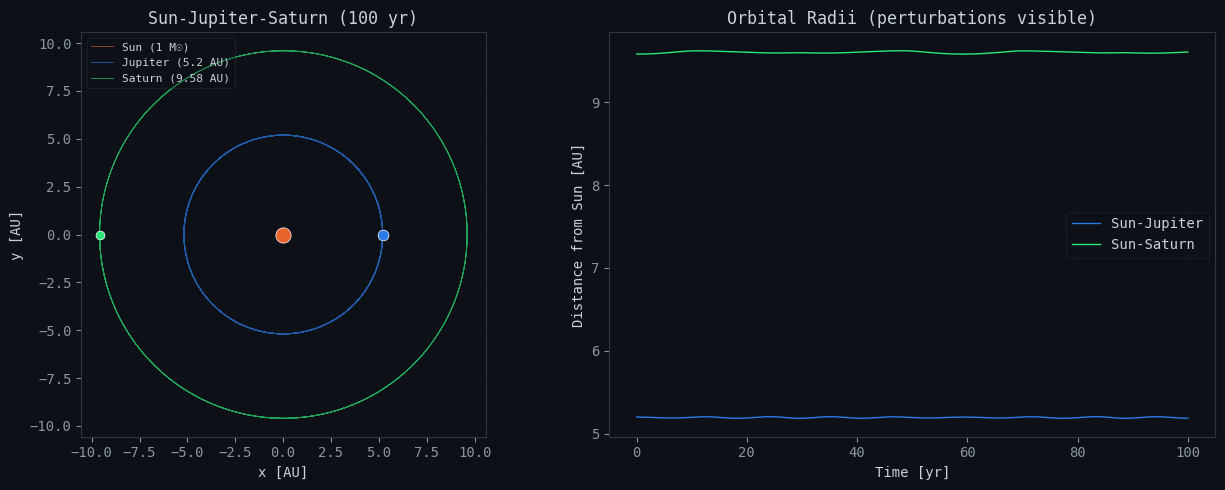

Jupiter period ≈ 338.4 yr  (expected: 11.86 yr)


In [7]:
ic, res = run_config('solar_system', n_points=8000)
pos = res.positions

labels = ['Sun (1 M☉)', 'Jupiter (5.2 AU)', 'Saturn (9.58 AU)']
sizes  = [120, 60, 40]

fig, axes = plt.subplots(1,2,figsize=(13,5))

for b,(c,lbl,sz) in enumerate(zip(BODY_COLORS, labels, sizes)):
    axes[0].plot(pos[:,b,0], pos[:,b,1], color=c, lw=0.6, alpha=0.7, label=lbl)
    axes[0].scatter(pos[0,b,0], pos[0,b,1], color=c, s=sz, zorder=5, edgecolors='white', lw=0.5)
axes[0].set_title('Sun-Jupiter-Saturn (100 yr)')
axes[0].set_xlabel('x [AU]'); axes[0].set_ylabel('y [AU]')
axes[0].set_aspect('equal'); axes[0].legend(fontsize=8); axes[0].grid(True,alpha=0.2)

# Jupiter and Saturn separations from Sun
d_jup = np.linalg.norm(pos[:,1,:] - pos[:,0,:], axis=1)
d_sat = np.linalg.norm(pos[:,2,:] - pos[:,0,:], axis=1)
axes[1].plot(res.t, d_jup, color=BODY_COLORS[1], lw=1, label='Sun-Jupiter')
axes[1].plot(res.t, d_sat, color=BODY_COLORS[2], lw=1, label='Sun-Saturn')
axes[1].set_title('Orbital Radii (perturbations visible)')
axes[1].set_xlabel('Time [yr]'); axes[1].set_ylabel('Distance from Sun [AU]')
axes[1].legend(); axes[1].grid(True,alpha=0.2)

plt.tight_layout(); plt.show()
print(f'Jupiter period ≈ {res.duration / (d_jup.argmin()/len(d_jup)*res.n_steps/len(d_jup)):.1f} yr  (expected: 11.86 yr)')

## 6. Gallery: All Configurations Side by Side

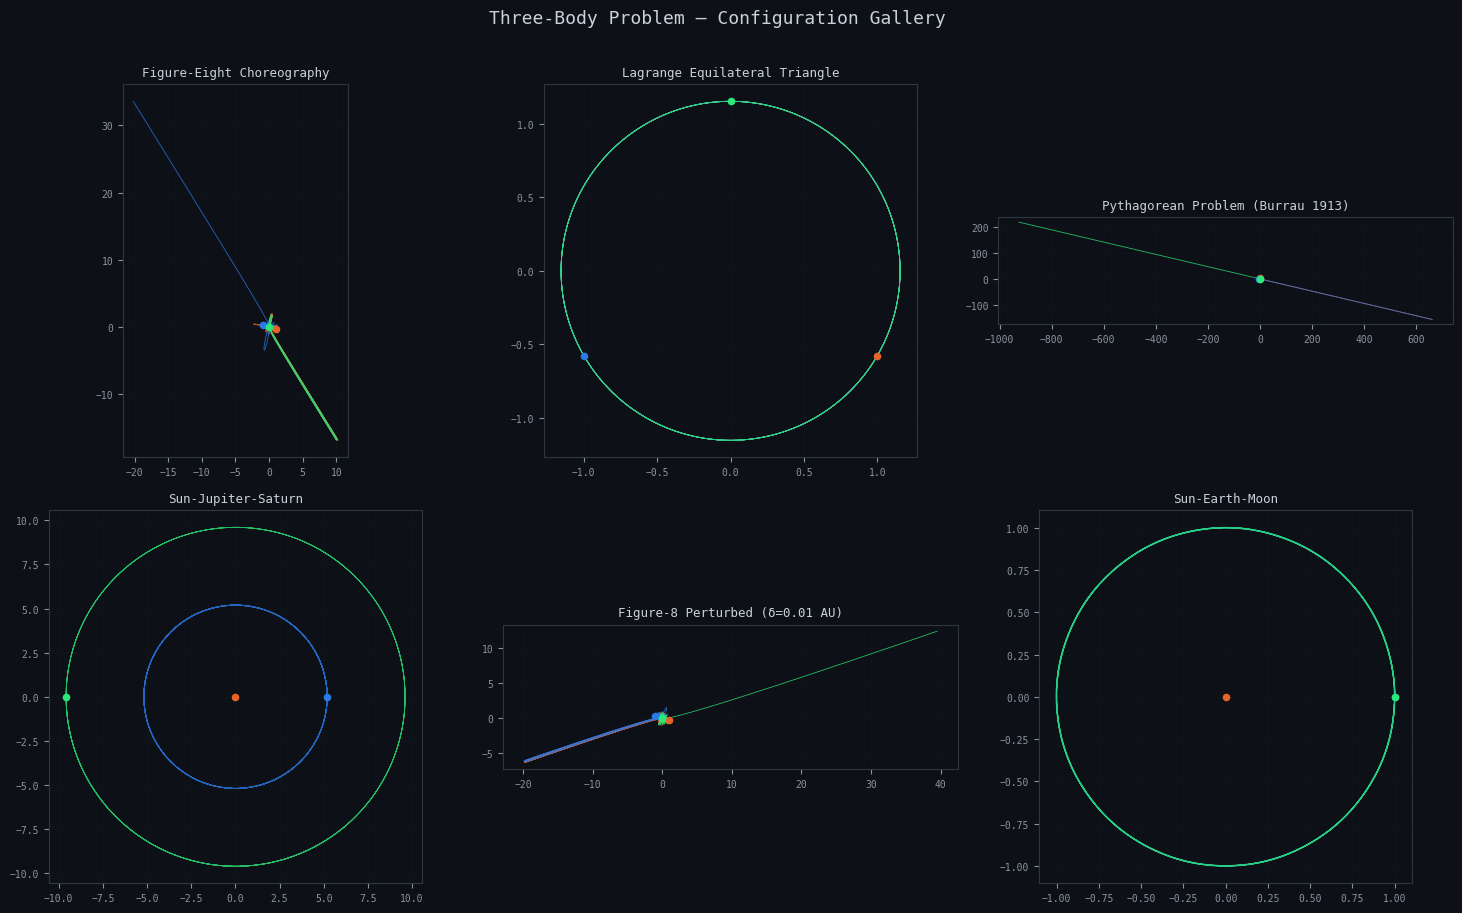

In [8]:
configs = ['figure_eight','lagrange_triangle','pythagorean',
           'solar_system','figure_eight_perturbed','sun_earth_moon']
fig, axes = plt.subplots(2,3,figsize=(15,9))
axes = axes.flatten()

for ax, name in zip(axes, configs):
    try:
        ic, res = run_config(name, n_points=3000)
        pos = res.positions
        for b,c in enumerate(BODY_COLORS):
            ax.plot(pos[:,b,0], pos[:,b,1], color=c, lw=0.6, alpha=0.8)
            ax.scatter(pos[0,b,0],pos[0,b,1],color=c,s=20,zorder=5)
        ax.set_title(ic['name'], fontsize=9)
        ax.set_aspect('equal'); ax.grid(True,alpha=0.15)
        ax.tick_params(labelsize=7)
    except Exception as e:
        ax.set_title(f'{name}\n(error: {e})', fontsize=8)

fig.suptitle('Three-Body Problem — Configuration Gallery', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## ✅ Summary

| Config | Type | Stable? | Key physics |
|--------|------|---------|-------------|
| Figure-Eight | Choreography | Yes (isolated) | Variational solution |
| Lagrange Triangle | Rigid rotation | Yes (equal mass) | Angular momentum balance |
| Pythagorean | Chaotic | No — ejection | Lyapunov instability |
| Solar System | Hierarchical | Yes (long-term) | Mass ratio separation |
| Perturbed Figure-8 | Chaotic | No | Lyapunov exponent visible |
| Sun-Earth-Moon | Hierarchical | Yes | Perturbation theory |

**Next:** `03_chaos_and_lyapunov.ipynb` — quantify chaos with the Lyapunov exponent.